In [ ]:
import pandas as pd
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="pastel")
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('gk_qna_dataset.csv')
display(df.head())

,question,answer
0,"What is the capital of ""France""?",Paris
1,"What is the capital of ""Germany""?",Berlin
2,"What is the capital of ""Italy""?",Rome
3,"What is the capital of ""Spain""?",Madrid
4,"What is the capital of ""Japan""?",Tokyo


# Data Distribution

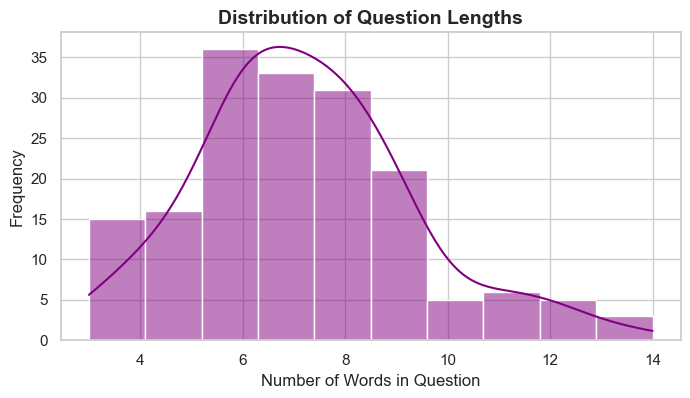

In [ ]:
df['question_length'] = df['question'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 4))
sns.histplot(df['question_length'], bins=10, kde=True, color='purple')
plt.title('Distribution of Question Lengths', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words in Question', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Tokenization & Vocabulary

In [8]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[\"']", "", text) 
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"[\s+]", " ", text).strip()
    return text.split()

vocab = {'<UNK>': 0}

def build_vocab(row):
    merged_tokens = tokenize(row['question']) + tokenize(row['answer'])
    for token in merged_tokens:
        if token not in vocab:
            vocab[token] = len(vocab)

df.apply(build_vocab, axis=1)
print(f"Total words in Vocabulary: {len(vocab)}")

def text_to_indices(text, vocab):
    return [vocab[token] if token in vocab else vocab['<UNK>'] for token in tokenize(text)]

Total words in Vocabulary: 243


# Dataset & DataLoader

In [9]:
class QADataset(Dataset):
    def __init__(self, df, vocab):
        self.df = df
        self.vocab = vocab
        
    def __len__(self):
        return self.df.shape[0]
    
    def __getitem__(self, index):
        numerical_question = text_to_indices(self.df.iloc[index]['question'], self.vocab)
        numerical_answer = text_to_indices(self.df.iloc[index]['answer'], self.vocab)
        
        return torch.tensor(numerical_question), torch.tensor(numerical_answer)

dataset = QADataset(df, vocab)
train_loader = DataLoader(dataset, batch_size=1, shuffle=True)

# Model Architecture (RNN)

In [10]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, hidden_size=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, question):
        embedded = self.embedding(question)
        _, final = self.rnn(embedded)
        return self.fc(final.squeeze(0))

model = SimpleRNN(vocab_size=len(vocab))

# Training Loop & Loss Curve

Training Started...
Epoch  10/40  |  Loss: 0.2588
Epoch  20/40  |  Loss: 0.0297
Epoch  30/40  |  Loss: 0.0088
Epoch  40/40  |  Loss: 0.0033


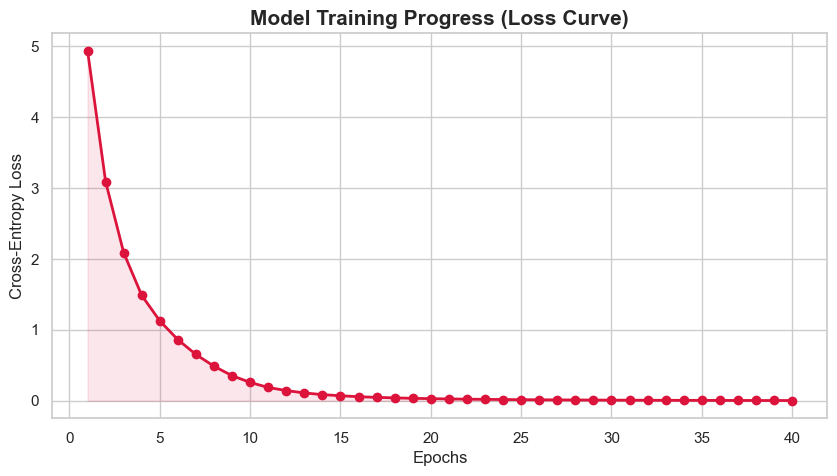

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 40
loss_history = []

print("Training Started...")
for epoch in range(epochs):
    total_loss = 0
    for question, answer in train_loader:
        optimizer.zero_grad()
        output = model(question)
        target = answer[0][0].unsqueeze(0)
        
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs}  |  Loss: {avg_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', color='crimson', linewidth=2)
plt.title('Model Training Progress (Loss Curve)', fontsize=15, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.fill_between(range(1, epochs + 1), loss_history, color='crimson', alpha=0.1)
plt.show()

# Word Embeddings Visualization

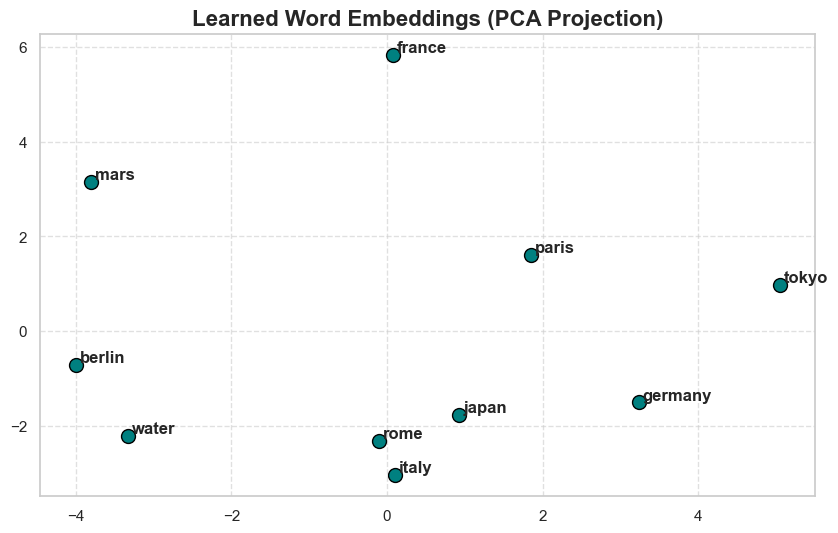

In [ ]:
words_to_plot = ['france', 'paris', 'germany', 'berlin', 'japan', 'tokyo', 'italy', 'rome', 'water', 'mars']
indices = [vocab[w] for w in words_to_plot if w in vocab]
found_words = [w for w in words_to_plot if w in vocab]

embeddings = model.embedding.weight[indices].detach().numpy()

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='teal', s=100, edgecolors='black')

for i, word in enumerate(found_words):
    plt.annotate(word, (vectors_2d[i, 0] + 0.05, vectors_2d[i, 1] + 0.05), fontsize=12, fontweight='bold')

plt.title('Learned Word Embeddings (PCA Projection)', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Prediction & Results Output

In [ ]:
idx_to_word = {idx: word for word, idx in vocab.items()}

def predict(question_text, model, vocab, idx_to_word):
    model.eval()
    with torch.no_grad():
        indices = text_to_indices(question_text, vocab)
        if not indices:
            return "<UNK>"
        x = torch.tensor(indices).unsqueeze(0)
        pred = torch.argmax(model(x), dim=1).item()
    return idx_to_word.get(pred, "<UNK>")

tests = [
    "What is the capital of France?",
    "What is H2O commonly called?",
    "Which planet is known as the red planet?",
    "Which bird cannot fly?",
    "What is the capital of Japan?"
]

results = []
for q in tests:
    results.append({"Question": q, "Predicted Answer": predict(q, model, vocab, idx_to_word)})

df_results = pd.DataFrame(results)

styled_results = df_results.style.set_properties(**{'background-color': '#f4f4f9', 'color': 'black', 'border-color': 'white'}) \
                 .set_table_styles([{'selector': 'th', 'props': [('background-color', '#4b4b4b'), ('color', 'white')]}])
display(styled_results)

,Question,Predicted Answer
0,What is the capital of France?,paris
1,What is H2O commonly called?,water
2,Which planet is known as the red planet?,mars
3,Which bird cannot fly?,ostrich
4,What is the capital of Japan?,tokyo
